In [1]:
from collections import defaultdict, namedtuple
from dataclasses import dataclass
from datetime import date, datetime, timedelta
from decimal import Decimal
from statistics import mean
import json
import random
import toml

import matplotlib.dates as pltd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import seaborn as sns

from sqlalchemy import create_engine
from sqlalchemy import desc, asc
from sqlalchemy import select, and_, or_
from sqlalchemy.orm import Session, lazyload, joinedload

from ss13tools.settings import make_engine
from ss13tools.model import Round, Feedback, LegacyPopulation

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

local_engine = make_engine("settings_local.toml")
local_session = Session(local_engine)

In [3]:
query = session.query(Round.id, Feedback.datetime, Feedback.json).join(Round).filter(
        Feedback.key_name == 'lavaland_mob_spawns',
        Round.start_datetime >= datetime(2024, 8, 3),
        Round.start_datetime < datetime(2024, 9, 25)).limit(170)

prod_mob_spawns = pd.read_sql_query(query.statement, session.connection())

In [64]:
query = session.query(Feedback.datetime, Feedback.json).join(Round).filter(
    Feedback.key_name == 'lavaland_mob_spawns',
    Round.id.in_(session
    .query(Feedback.round_id)
    .where(and_(
        Feedback.key_name == 'testmerged_prs',
        or_(Feedback.json["data"].regexp_match('0ec15cd'),
            Feedback.json["data"].regexp_match('3601468'),
            Feedback.json["data"].regexp_match('d408cb3')))))).limit(len(prod_mob_spawns))

tm_mob_spawns = pd.read_sql_query(query.statement, session.connection())

In [84]:
pool_mob_spawns

,id,datetime,json
0,4745,2024-10-08 00:14:12,{'data': {'/obj/structure/flora/ash/cap_shroom...
1,4746,2024-10-08 00:15:10,{'data': {'/obj/structure/flora/ash/stem_shroo...
2,4747,2024-10-08 00:16:18,{'data': {'/obj/structure/flora/ash/tall_shroo...
3,4748,2024-10-08 00:17:13,{'data': {'/obj/structure/spawner/lavaland/gol...
4,4749,2024-10-08 00:18:21,{'data': {'/obj/effect/landmark/mob_spawner/wa...
...,...,...,...
165,4913,2024-10-08 02:59:55,{'data': {'/obj/structure/spawner/lavaland': 5...
166,4914,2024-10-08 03:00:51,{'data': {'/mob/living/simple_animal/hostile/m...
167,4915,2024-10-08 03:02:01,{'data': {'/obj/structure/spawner/lavaland': 3...
168,4916,2024-10-08 03:02:59,{'data': {'/obj/effect/landmark/mob_spawner/ab...


In [50]:
# query = local_session.query(Round.id, Feedback.datetime, Feedback.json).join(Round).filter(
#         Feedback.key_name == 'lavaland_mob_spawns',
#         Round.id > 4673, Round.id <= 4742).limit(len(prod_mob_spawns))

# query = local_session.query(Round.id, Feedback.datetime, Feedback.json).join(Round).filter(
#         Feedback.key_name == 'lavaland_mob_spawns',
#         Round.id > 4743, Round.id <= 4919).limit(len(prod_mob_spawns))

# query = local_session.query(Round.id, Feedback.datetime, Feedback.json).join(Round).filter(
#         Feedback.key_name == 'lavaland_mob_spawns',
#         Round.id > 4920, Round.id <= 5280).limit(len(prod_mob_spawns))

# query = local_session.query(Round.id, Feedback.datetime, Feedback.json).join(Round).filter(
#         Feedback.key_name == 'lavaland_mob_spawns',
#         Round.id > 5281, Round.id <= 5479).limit(len(prod_mob_spawns))

with Session(local_engine) as local_session:
    
    query = local_session.query(Round.id, Feedback.datetime, Feedback.json).join(Round).filter(
            Feedback.key_name == 'lavaland_mob_spawns',
            Round.id >= 5510)
    
    pool_mob_spawns = pd.read_sql_query(query.statement, local_session.connection())

In [42]:
len(prod_mob_spawns)

170

In [43]:
len(pool_mob_spawns)

2

In [44]:
def apply_total_spawner_counts(text):
    keys, values = zip(*[("total", sum(v for k, v in text['data'].items() if k.startswith("/obj/structure/spawner/lavaland")))])
    return pd.Series(values, index=keys)

def get_total_spawner_counts(df):
    return pd.concat([df, df['json'].apply(apply_total_spawner_counts)], axis=1).drop(['json'], axis=1)
    
def apply_individual_ruin_counts(text):
    keys, values = zip(*[(p.replace('.dmm', ''), sum(1 for ruin in text['data'].values() if ruin["map"] == p)) for p in problem_ruins])
    return pd.Series(values, index=keys)

def get_individual_ruin_counts(df):
    return pd.concat([df, raw_prod_ruins['json'].apply(apply_individual_ruin_counts)], axis=1).drop(['json'], axis=1)

def apply_total_fauna_counts(text):
    keys, values = zip(*[("total", sum(v for k, v in text['data'].items() if k.startswith("/obj/effect/landmark/mob_spawner")))])
    return pd.Series(values, index=keys)

def get_total_fauna_counts(df):
    return pd.concat([df, df['json'].apply(apply_total_fauna_counts)], axis=1).drop(['json'], axis=1)

def apply_total_megafauna_counts(text):
    keys, values = zip(*[("total", sum(v for k, v in text['data'].items() if k.startswith("/mob/living/simple_animal/hostile/megafauna")))])
    return pd.Series(values, index=keys)

def get_total_megafauna_counts(df):
    return pd.concat([df, df['json'].apply(apply_total_megafauna_counts)], axis=1).drop(['json'], axis=1)

def get_lim(df):
    return np.logical_and(
        df < df.quantile(0.99, numeric_only=False),
        df > df.quantile(0.01, numeric_only=False))

def limit(df):
    lim = get_lim(df)
    df.loc[:, ['total']] = df.where(lim, np.nan)
    df.dropna(inplace=True)
    return df

In [45]:
sns.set_theme()

In [51]:
pool_normalized_spawns = pd.json_normalize(pool_mob_spawns.json)
pool_normalized_spawns.columns = pool_normalized_spawns.columns.str.replace("data./mob/living/simple_animal/hostile/", "") 
pool_normalized_spawns.columns = pool_normalized_spawns.columns.str.replace("data./obj/structure/spawner/lavaland", "tendril")
pool_normalized_spawns.columns = pool_normalized_spawns.columns.str.replace("data./obj/effect/landmark/mob_spawner", "mob")
pool_normalized_spawns = pool_normalized_spawns.reindex(sorted(pool_normalized_spawns.columns), axis=1)

In [52]:
pool_normalized_spawns.fillna(0).astype('int64')

,megafauna/ancient_robot,megafauna/bubblegum,megafauna/colossus,megafauna/dragon,mob/abandoned_minebot,mob/goldgrub,mob/goliath,mob/gutlunch,mob/legion,mob/watcher,tendril,tendril/goliath,tendril/legion
0,1,1,3,3,2,4,18,1,6,19,2,2,3
1,1,1,1,6,1,5,17,1,10,16,0,3,0
2,1,1,2,8,2,3,16,0,16,13,0,3,8
3,1,1,0,9,3,0,8,2,14,14,4,3,8
4,1,1,4,6,1,3,18,3,10,15,2,3,6
5,1,1,3,6,3,6,20,0,13,8,7,7,1
6,1,1,4,5,0,4,22,1,10,13,4,9,2


In [73]:
spawner_unique_vals = set(get_total_spawner_counts(prod_mob_spawns).total.unique()).union(set(get_total_spawner_counts(tm_mob_spawns).total.unique()))
spawner_max = max(unique_vals)
spawner_min = min(unique_vals)

In [26]:
current_palette = sns.color_palette()
secondary_bars = [current_palette[0], current_palette[2]]

<Axes: title={'center': 'Tendrils spawned per round, prod sample vs pools, 170 rounds'}, xlabel='Number of tendrils spawned per round', ylabel='Number of rounds'>

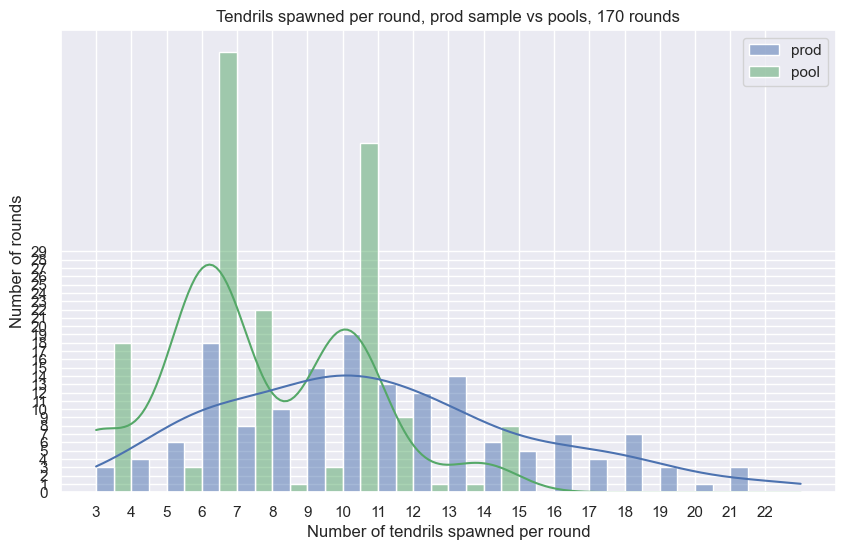

In [107]:
prod_tendril_counts = limit(get_total_spawner_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1))
pool_tendril_counts = limit(get_total_spawner_counts(pool_mob_spawns))

spawner_unique_vals = set(prod_tendril_counts.total.unique()).union(set(pool_tendril_counts.total.unique()))
spawner_max = max(spawner_unique_vals)
spawner_min = min(spawner_unique_vals)

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)

ax.locator_params(axis='x', integer=True)
ax.set(title=f'Tendrils spawned per round, prod sample vs pools, {len(prod_mob_spawns)} rounds')
ax.yaxis.set_ticks(np.arange(0, 30, 1))
ax.set_xlabel("Number of tendrils spawned per round")
ax.set_ylabel("Number of rounds")

ax.xaxis.set_ticks(np.arange(spawner_min, spawner_max, 1))
sns.histplot(data={
    'prod': prod_tendril_counts.total,
    'pool': pool_tendril_counts.total,
    }, multiple='dodge', bins=np.arange(spawner_min, spawner_max, 1), kde=True, palette=secondary_bars)


# plt.savefig('tendril_spawn_histogram.png')

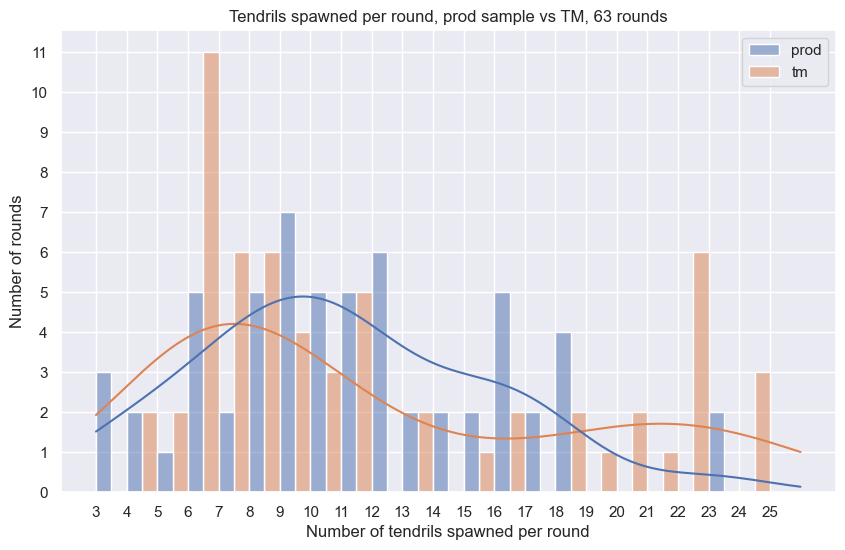

In [166]:
prod_tendril_counts = limit(get_total_spawner_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1))
tm_tendril_counts = limit(get_total_spawner_counts(tm_mob_spawns))

spawner_unique_vals = set(prod_tendril_counts.total.unique()).union(set(tm_tendril_counts.total.unique()))
spawner_max = max(spawner_unique_vals)
spawner_min = min(spawner_unique_vals)

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)

ax.locator_params(axis='x', integer=True)
ax.set(title='Tendrils spawned per round, prod sample vs TM, 63 rounds')
ax.yaxis.set_ticks(np.arange(0, 15, 1))
ax.set_xlabel("Number of tendrils spawned per round")
ax.set_ylabel("Number of rounds")

ax.xaxis.set_ticks(np.arange(spawner_min, spawner_max, 1))
sns.histplot(data={
    'prod': prod_tendril_counts.total,
    'tm': tm_tendril_counts.total,
    }, multiple='dodge', bins=np.arange(spawner_min, spawner_max, 1), kde=True)


plt.savefig('tendril_spawn_histogram.png')

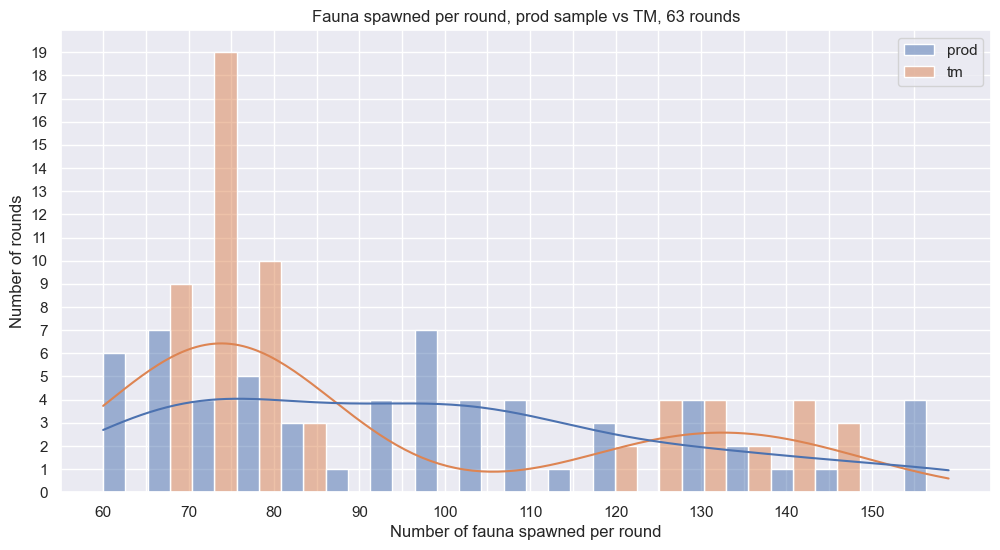

In [179]:
prod_fauna_counts = limit(get_total_fauna_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1))
tm_fauna_counts = limit(get_total_fauna_counts(tm_mob_spawns))

fauna_unique_vals = set(prod_fauna_counts.total.unique()).union(set(tm_fauna_counts.total.unique()))
fauna_max = max(fauna_unique_vals)
fauna_min = min(fauna_unique_vals)

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

ax.locator_params(axis='x', integer=True)
ax.set(title='Fauna spawned per round, prod sample vs TM, 63 rounds')
ax.yaxis.set_ticks(np.arange(0, 20, 1))
ax.set_xlabel("Number of fauna spawned per round")
ax.set_ylabel("Number of rounds")
# ax.tick_params(axis='x', labelrotation=-45)

ax.xaxis.set_ticks(np.arange(fauna_min, fauna_max, 5))

for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 2 != 0:
        label.set_visible(False)

# sns.histplot(data={
#     'prod': prod_fauna_counts.total,
#     'tm': tm_fauna_counts.total,
#     }, multiple='dodge', bins=np.arange(fauna_min, fauna_max, 1), kde=True)

sns.histplot(data={
    'prod': prod_fauna_counts.total,
    'tm': tm_fauna_counts.total,
    }, multiple='dodge', bins=int((fauna_max-fauna_min) /5), kde=True)


plt.savefig('fauna_spawn_buckets_histogram.png')

<Axes: title={'center': 'Fauna spawned per round, prod sample vs pool, 170 rounds'}, xlabel='Number of fauna spawned per round', ylabel='Number of rounds'>

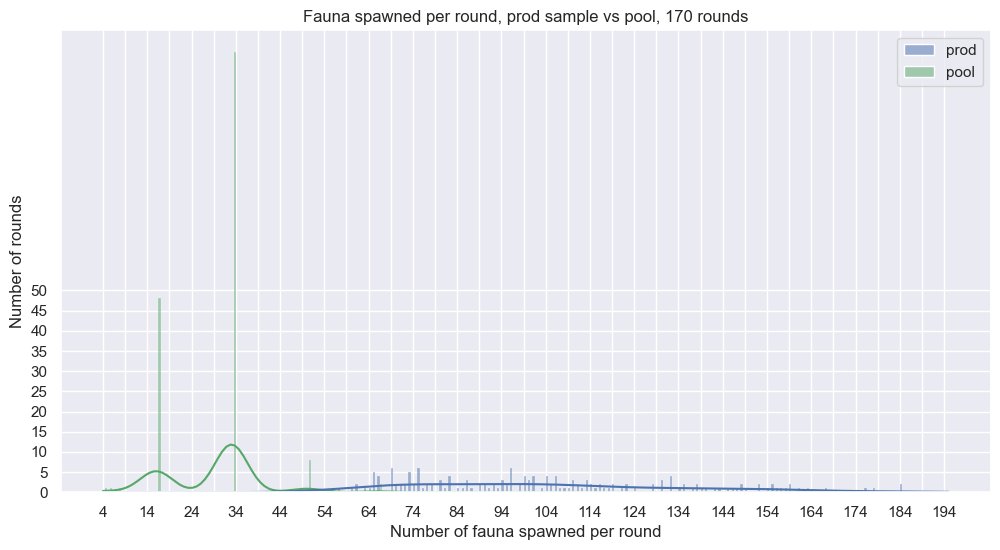

In [115]:
# prod_fauna_counts = limit(get_total_fauna_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1))
# pool_fauna_counts = limit(get_total_fauna_counts(pool_mob_spawns))

prod_fauna_counts = get_total_fauna_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1)
pool_fauna_counts = get_total_fauna_counts(pool_mob_spawns)


fauna_unique_vals = set(prod_fauna_counts.total.unique()).union(set(pool_fauna_counts.total.unique()))
fauna_max = max(fauna_unique_vals)
fauna_min = min(fauna_unique_vals)

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

ax.locator_params(axis='x', integer=True)
ax.set(title=f'Fauna spawned per round, prod sample vs pool, {len(prod_mob_spawns)} rounds')
ax.yaxis.set_ticks(np.arange(0, 55, 5))
ax.set_xlabel("Number of fauna spawned per round")
ax.set_ylabel("Number of rounds")
# ax.tick_params(axis='x', labelrotation=-45)

ax.xaxis.set_ticks(np.arange(fauna_min, fauna_max, 5))

for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 2 != 0:
        label.set_visible(False)

sns.histplot(data={
    'prod': prod_fauna_counts.total,
    'pool': pool_fauna_counts.total,
    }, multiple='dodge', bins=np.arange(fauna_min, fauna_max, 1), kde=True, palette=secondary_bars)

# sns.histplot(data={
#     'prod': prod_fauna_counts.total,
#     'pool': pool_fauna_counts.total,
#     }, multiple='dodge', bins=int((fauna_max-fauna_min) /5), kde=True, palette=secondary_bars)


# plt.savefig('fauna_spawn_buckets_histogram.png')

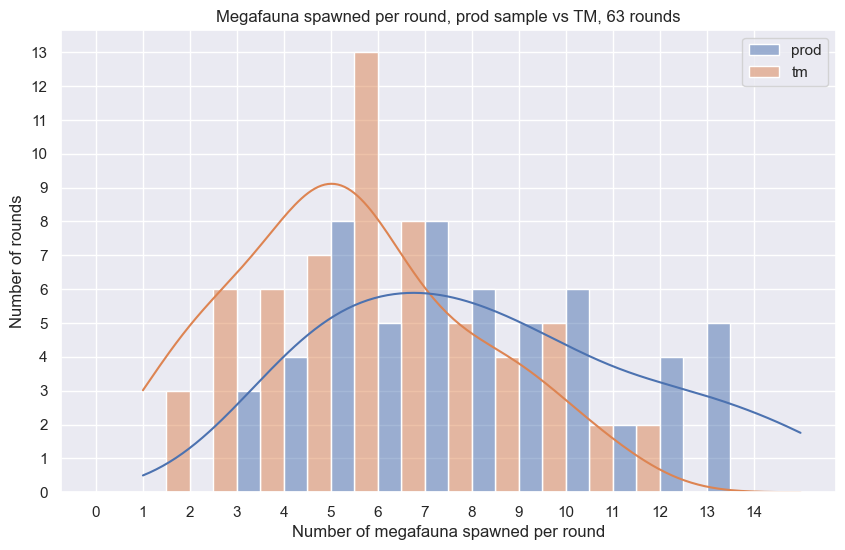

In [167]:
prod_megafauna_counts = limit(get_total_megafauna_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1))
tm_megafauna_counts = limit(get_total_megafauna_counts(tm_mob_spawns))

fauna_unique_vals = set(prod_megafauna_counts.total.unique()).union(set(tm_megafauna_counts.total.unique()))
fauna_max = max(fauna_unique_vals)
fauna_min = min(fauna_unique_vals)

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)

ax.locator_params(axis='x', integer=True)
ax.set(title='Megafauna spawned per round, prod sample vs TM, {len(prod_mob_spawns)} rounds')
ax.yaxis.set_ticks(np.arange(0, 15, 1))
ax.set_xlabel("Number of megafauna spawned per round")
ax.set_ylabel("Number of rounds")
# ax.tick_params(axis='x', labelrotation=-45)

ax.xaxis.set_ticks(np.arange(0, fauna_max, 1))

# for index, label in enumerate(ax.xaxis.get_ticklabels()):
#     if index % 2 != 0:
#         label.set_visible(False)

sns.histplot(data={
    'prod': prod_megafauna_counts.total,
    'tm': tm_megafauna_counts.total,
    }, multiple='dodge', bins=np.arange(0, fauna_max, 1), kde=True)


plt.savefig('megafauna_spawn_histogram.png')

<Axes: title={'center': 'Megafauna spawned per round, prod sample vs TM, 170 rounds'}, xlabel='Number of megafauna spawned per round', ylabel='Number of rounds'>

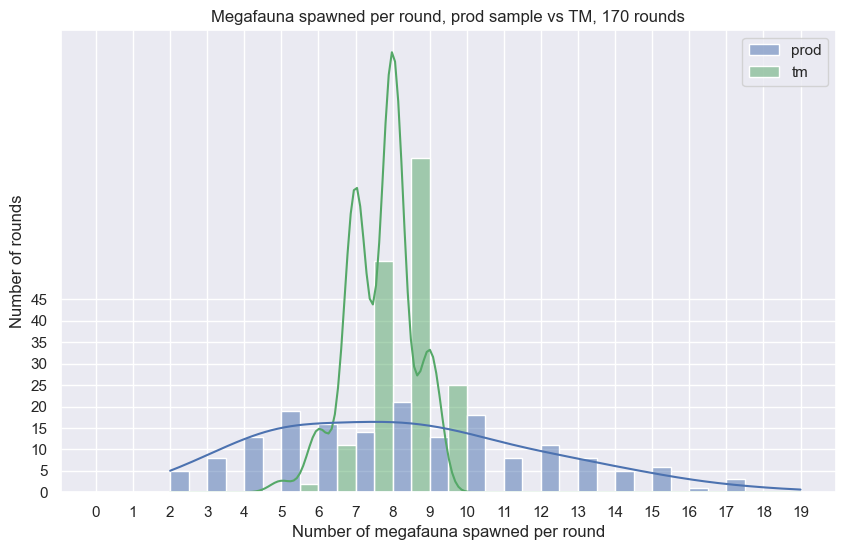

In [114]:
# prod_megafauna_counts = limit(get_total_megafauna_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1))
# pool_megafauna_counts = limit(get_total_megafauna_counts(pool_mob_spawns))

prod_megafauna_counts = get_total_megafauna_counts(prod_mob_spawns).drop(['id', 'datetime'], axis=1)
pool_megafauna_counts = get_total_megafauna_counts(pool_mob_spawns)


fauna_unique_vals = set(prod_megafauna_counts.total.unique()).union(set(pool_megafauna_counts.total.unique()))
fauna_max = max(fauna_unique_vals)
fauna_min = min(fauna_unique_vals)

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)

ax.locator_params(axis='x', integer=True)
ax.set(title=f'Megafauna spawned per round, prod sample vs TM, {len(prod_mob_spawns)} rounds')
ax.yaxis.set_ticks(np.arange(0, 50, 5))
ax.set_xlabel("Number of megafauna spawned per round")
ax.set_ylabel("Number of rounds")
# ax.tick_params(axis='x', labelrotation=-45)

ax.xaxis.set_ticks(np.arange(0, fauna_max + 1, 1))

# for index, label in enumerate(ax.xaxis.get_ticklabels()):
#     if index % 2 != 0:
#         label.set_visible(False)

sns.histplot(data={
    'prod': prod_megafauna_counts.total,
    'tm': pool_megafauna_counts.total,
    }, multiple='dodge', bins=np.arange(0, fauna_max, 1), kde=True, palette=secondary_bars)


# plt.savefig('megafauna_spawn_histogram.png')

In [120]:
df = get_total_fauna_counts(pool_mob_spawns)
df[df.total == 33]

,id,datetime,total
0,5282,2024-10-08 09:27:56,33
1,5283,2024-10-08 09:28:58,33
3,5285,2024-10-08 09:30:49,33
5,5287,2024-10-08 09:33:08,33
7,5289,2024-10-08 09:35:02,33
...,...,...,...
162,5447,2024-10-08 12:12:56,33
165,5450,2024-10-08 12:15:56,33
166,5451,2024-10-08 12:16:53,33
167,5452,2024-10-08 12:18:06,33
